In [5]:
import numpy as np
import xarray as xr
import rioxarray 
import matplotlib as plt
import geopandas as gpd
# AI use statement: Google Chrome AI overviews were referenced in the creation of this code

In [2]:
redBand = rioxarray.open_rasterio(r"C:\Users\cquering\Documents\Repository\408\ce8\Landsat9\LC09_L2SP_021036_20260222_20260223_02_T1\LC09_L2SP_021036_20260222_20260223_02_T1_SR_B4.TIF")
nearIR = rioxarray.open_rasterio(r"C:\Users\cquering\Documents\Repository\408\ce8\Landsat9\LC09_L2SP_021036_20260222_20260223_02_T1\LC09_L2SP_021036_20260222_20260223_02_T1_SR_B5.TIF")
HSV_polygon = gpd.read_file(r"C:\Users\cquering\Documents\Repository\408\ce8\HSV_boundary\Boundary_City_Huntsville_poly.shp")


In [3]:
normed_redBand = (redBand/redBand.max())*256
normed_nearIR = (nearIR/nearIR.max())*256
CRS_HSV = HSV_polygon.to_crs(normed_redBand.rio.crs)

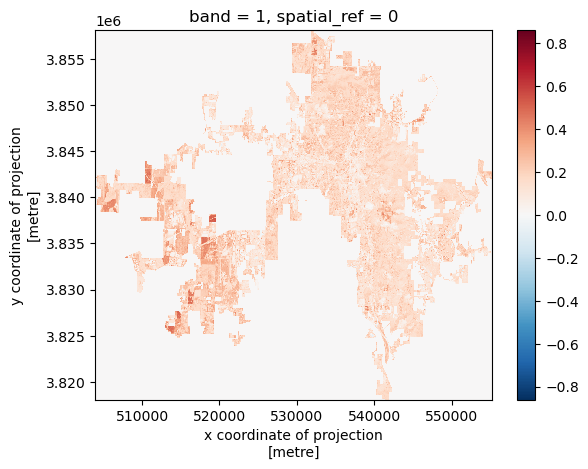

In [4]:
ndvi = (normed_nearIR[0]-normed_redBand)/(normed_nearIR[0]+normed_redBand)
clipped_ndvi = ndvi.rio.clip(CRS_HSV.geometry)
clipped_ndvi.plot()
